In [1]:
# !ls -R "/kaggle/input/erythrocytesidb-sca/Version 2, erythrocytesIDB 2021/"

In [2]:
import numpy as np
import pandas as pd 
import shutil
import random
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import time
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import timm
import argparse
import json
from collections import defaultdict
from datetime import datetime
import copy
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc, roc_auc_score)
from collections import OrderedDict

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [3]:
def split_dataset(input_dir, output_dir, train_ratio, val_ratio, test_ratio):
    if os.path.exists(output_dir):
        print(f"Directory {output_dir} already exists. Removing it.")
        shutil.rmtree(output_dir)
    os.makedirs(output_dir, exist_ok=True)

    # Create subfolders
    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(output_dir, split), exist_ok=True)

    print(f"Splitting data from: {input_dir}")
    for class_name in os.listdir(input_dir):
        class_path = os.path.join(input_dir, class_name)
        if not os.path.isdir(class_path):
            print(f"Skipping non-directory: {class_name}")
            continue
        
        # Filter for valid image files and ignore hidden files like .DS_Store
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg','.jpeg','.png')) and not f.startswith('.')]
        if not images:
            print(f"No images found in: {class_path}")
            continue
            
        random.shuffle(images)

        n_total = len(images)
        n_train = int(n_total * train_ratio)
        n_val   = int(n_total * val_ratio)
        n_test  = n_total - n_train - n_val
        
        # Ensure at least one image in test if val is small
        if n_test == 0 and n_val > 0:
            n_val -= 1
            n_test += 1
        
        if n_train == 0 or n_test == 0:
             print(f"Warning: Class {class_name} has only {n_total} images. Splitting might be suboptimal.")
             # Adjust to ensure some data in train/test if possible
             if n_total > 2:
                 n_train = max(1, n_train)
                 n_test = max(1, n_test)
                 n_val = n_total - n_train - n_test
             elif n_total == 2:
                 n_train = 1
                 n_test = 1
                 n_val = 0
             elif n_total == 1:
                 n_train = 1
                 n_val = 0
                 n_test = 0


        splits = {
            "train": images[:n_train],
            "val":   images[n_train:n_train+n_val],
            "test":  images[n_train+n_val:]
        }
        
        print(f"  Class '{class_name}': Total={n_total} -> Train={len(splits['train'])}, Val={len(splits['val'])}, Test={len(splits['test'])}")

        for split, split_imgs in splits.items():
            split_dir = os.path.join(output_dir, split, class_name)
            os.makedirs(split_dir, exist_ok=True)
            for img in split_imgs:
                shutil.copy2(os.path.join(class_path, img), os.path.join(split_dir, img))

    print(f"✅ Dataset split completed! Train/Val/Test saved in {output_dir}")

In [4]:
CHECKPOINT_DIR = "checkpoints"
OUTPUT_DIR = "outputs"
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_WORKERS = 4 # Using 4 based on Kaggle's environment
LR = 1e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 100
EARLY_STOPPING_PATIENCE = 10
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

In [6]:
def get_dataloaders(data_dir, img_size=IMG_SIZE, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    train_transforms = transforms.Compose([
        transforms.RandomResizedCrop(img_size),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2,0.2,0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    val_test_transforms = transforms.Compose([
        transforms.Resize(int(img_size*1.1)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])

    train_ds = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transforms)
    val_ds   = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_test_transforms)
    test_ds  = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_test_transforms)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    class_names = train_ds.classes
    print(f"Data loaders created. Found classes: {class_names}")
    return train_loader, val_loader, test_loader, class_names

# --- Attention (SE block) (Cell 9) ---
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        w = self.fc(x).view(b, c, 1, 1)
        return x * w

In [7]:
# (Using the relevant parts for resnet and vgg from your notebook)
def add_se_to_model(model, target_layer_name=None):
    # -------- RESNET (ResNet50 etc) -----------
    if hasattr(model, "layer4"):
        orig = model.layer4
        last_conv_channels = None
        for m in reversed(list(orig.modules())):
            if isinstance(m, nn.Conv2d):
                last_conv_channels = m.out_channels
                break
        if last_conv_channels is not None:
            se = SEBlock(last_conv_channels)
            model.layer4 = nn.Sequential(orig, se)
        return model

    # -------- VGG ----------
    if "VGG" in str(type(model)):
        last_conv_channels = None
        for m in reversed(list(model.features.modules())):
            if isinstance(m, nn.Conv2d):
                last_conv_channels = m.out_channels
                break
        if last_conv_channels:
            model.features = nn.Sequential(model.features, SEBlock(last_conv_channels))
        return model
        
    # --- Fallback for other models from your notebook ---
    # (EfficientNet, DenseNet, etc. would go here if needed)
    print(f"Warning: SE-Block not implemented for {type(model)}")
    return model

In [8]:
def build_model(name, num_classes, pretrained=True, use_se=True):
    name = name.lower()
    
    weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
    vgg_weights = models.VGG16_Weights.IMAGENET1K_V1 if pretrained else None
    effnet_weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None

    # ------------------ RESNET50 ------------------
    if name == "resnet50":
        model = models.resnet50(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        if use_se:
            model = add_se_to_model(model)
        return model

    # ------------------ VGG16 ------------------
    if name == "vgg16":
        model = models.vgg16(weights=vgg_weights)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        if use_se:
            model = add_se_to_model(model)
        return model
        
    # ------------------ EFFICIENTNET-B0 (Torchvision) ------------------
    if name in ["efficientnet_b0", "efficientnet"]:
        try:
            model = models.efficientnet_b0(weights=effnet_weights)
            model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
            if use_se:
                model = add_se_to_model(model)
            return model
        except Exception as e:
            print(f"Could not build torchvision efficientnet_b0: {e}. Falling back to timm.")
            model = timm.create_model("efficientnet_b0", pretrained=pretrained, num_classes=num_classes)
            return model

    # ------------------ UNKNOWN ------------------
    raise ValueError(f"Unknown model {name}")

In [9]:
def save_checkpoint(state, filename):
    torch.save(state, filename)

class EarlyStopping:
    def __init__(self, patience=EARLY_STOPPING_PATIENCE, minimize=False):
        self.patience = patience
        self.counter = 0
        self.best = None
        self.minimize = minimize
        self.best_epoch = 0

    def step(self, metric, epoch):
        if self.best is None:
            self.best = metric
            self.best_epoch = epoch
            return False
        improved = (metric < self.best) if self.minimize else (metric > self.best)
        if improved:
            self.best = metric
            self.best_epoch = epoch
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

def compute_metrics_all(y_true, y_pred, y_score, num_classes, class_names):
    # y_score: N x C probability scores for ROC/AUC
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    
    # multiclass ROC AUC (one-vs-rest)
    try:
        if num_classes > 2:
             y_true_one_hot = np.eye(num_classes)[y_true]
             roc_auc = roc_auc_score(
                 y_true_one_hot,
                 y_score, average="macro", multi_class="ovr"
             )
        else:
             # Binary case
             roc_auc = roc_auc_score(y_true, y_score[:, 1]) # Score for positive class
    except Exception as e:
        print(f"Could not compute ROC-AUC: {e}")
        roc_auc = None

    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": roc_auc, "classification_report": report}

def evaluate(model, loader, device, num_classes, class_names):
    model.eval()
    ys, ys_pred, ys_prob = [], [], []
    soft = nn.Softmax(dim=1)
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            
            # Handle InceptionV3 aux logits if present
            if isinstance(logits, tuple):
                logits = logits[0] 
                
            probs = soft(logits).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            ys.extend(yb.cpu().numpy().tolist())
            ys_pred.extend(preds.tolist())
            ys_prob.extend(probs.tolist())
    ys = np.array(ys)
    ys_pred = np.array(ys_pred)
    ys_prob = np.array(ys_prob)
    metrics = compute_metrics_all(ys, ys_pred, ys_prob, num_classes, class_names)
    cm = confusion_matrix(ys, ys_pred)
    return metrics, cm, ys, ys_pred, ys_prob

In [10]:
def train_and_evaluate(model_name, dataloaders, class_names, device, output_root, epochs=EPOCHS,
                       lr=LR, weight_decay=WEIGHT_DECAY, resume_checkpoint=None):
    train_loader, val_loader, test_loader = dataloaders
    num_classes = len(class_names)
    model = build_model(model_name, num_classes=num_classes, pretrained=True, use_se=True)
    model = model.to(device)

    # optimizer & scheduler
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5, verbose=True)

    start_epoch = 0
    history = defaultdict(list)
    best_val_f1 = -1.0

    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{model_name}_best.pth")
    resume_path = resume_checkpoint or None
    if resume_path and os.path.exists(resume_path):
        print(f"Resuming from {resume_path}")
        cp = torch.load(resume_path, map_location=device, weights_only=False)
        model.load_state_dict(cp['model_state'])
        optimizer.load_state_dict(cp['opt_state'])
        start_epoch = cp.get('epoch', 0) + 1
        history = cp.get('history', defaultdict(list))
        best_val_f1 = cp.get('best_val_f1', best_val_f1)

    early_stopper = EarlyStopping(patience=EARLY_STOPPING_PATIENCE, minimize=False) # Maximize F1

    criterion = nn.CrossEntropyLoss()

    for epoch in range(start_epoch, epochs):
        start_time = time.time()
        print(f"\n=== {model_name} Epoch {epoch+1}/{epochs} ===")
        
        # --- Train ---
        model.train()
        running_loss = 0.0
        all_preds = []
        all_targets = []
        for xb, yb in train_loader:
            xb = xb.to(device); yb = yb.to(device)
            optimizer.zero_grad()
            
            # Handle InceptionV3 aux logits during training if pretrained
            if "inception" in model_name and model.aux_logits:
                logits, aux_logits = model(xb)
                loss1 = criterion(logits, yb)
                loss2 = criterion(aux_logits, yb)
                loss = loss1 + 0.4*loss2 # As recommended in InceptionV3 paper
            else:
                logits = model(xb)
                loss = criterion(logits, yb)
                
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_targets.extend(yb.cpu().numpy().tolist())

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = accuracy_score(all_targets, all_preds)
        epoch_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['train_f1'].append(epoch_f1)

        # --- Validate ---
        val_metrics, val_cm, _, _, _ = evaluate(model, val_loader, device, num_classes, class_names)
        val_f1 = val_metrics['f1']
        val_acc = val_metrics['accuracy']
        
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['val_metrics'].append(val_metrics)
        
        epoch_time = time.time() - start_time
        print(f"Time: {epoch_time:.2f}s Train loss: {epoch_loss:.4f} acc: {epoch_acc:.4f} f1: {epoch_f1:.4f}")
        print(f"Val metrics: acc {val_acc:.4f} f1 {val_f1:.4f} roc_auc {val_metrics.get('roc_auc', 'N/A'):.4f}")

        # scheduler step on val f1
        scheduler.step(val_f1)

        # checkpoint
        is_best = val_f1 > best_val_f1
        if is_best:
            best_val_f1 = val_f1
            save_checkpoint({
                'epoch': epoch,
                'model_state': model.state_dict(),
                'opt_state': optimizer.state_dict(),
                'best_val_f1': best_val_f1,
                'history': history,
                'class_names': class_names
            }, checkpoint_path)
            print(f"Saved best checkpoint (Val F1: {best_val_f1:.4f}) to {checkpoint_path}")

        # early stopping
        stop = early_stopper.step(val_f1, epoch)
        if stop:
            print(f"Early stopping triggered after epoch {epoch+1}. Best epoch was {early_stopper.best_epoch + 1} with F1: {early_stopper.best:.4f}")
            break

    # --- Final Evaluation ---
    print("\nTraining finished. Loading best model for final evaluation...")
    # Load best model
    try:
        cp = torch.load(checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(cp['model_state'])
        print(f"Loaded best model from epoch {cp.get('epoch', -1)+1} with Val F1: {cp.get('best_val_f1', -1):.4f}")
    except Exception as e:
        print(f"Warning: Could not load best checkpoint {checkpoint_path}. Using last model. Error: {e}")

    print("Evaluating final model on train/val/test...")
    metrics_train, cm_train, _, _, _ = evaluate(model, train_loader, device, num_classes, class_names)
    metrics_val, cm_val, _, _, _ = evaluate(model, val_loader, device, num_classes, class_names)
    metrics_test, cm_test, y_test, y_test_pred, y_test_prob = evaluate(model, test_loader, device, num_classes, class_names)

    print("\n--- Test Set Performance ---")
    print(f"Accuracy:  {metrics_test['accuracy']:.4f}")
    print(f"F1-Macro:  {metrics_test['f1']:.4f}")
    print(f"Precision: {metrics_test['precision']:.4f}")
    print(f"Recall:    {metrics_test['recall']:.4f}")
    if metrics_test.get('roc_auc'):
        print(f"ROC-AUC:   {metrics_test['roc_auc']:.4f}")
    print("\nTest Confusion Matrix:")
    print(cm_test)
    print("\nTest Classification Report:")
    print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))


    # save model final (best model)
    final_path = os.path.join(OUTPUT_DIR, f"{model_name}_final.pth")
    torch.save({'model_state': model.state_dict(),
                'class_names': class_names}, final_path)
    print(f"Saved final (best) model to {final_path}")

    # save metrics and confusion matrices and histories
    timeid = datetime.now().strftime("%Y%m%d_%H%M%S")
    results_path = os.path.join(OUTPUT_DIR, f"{model_name}_results_{timeid}.json")
    out = {
        "model_name": model_name,
        "best_epoch": early_stopper.best_epoch,
        "best_val_f1": early_stopper.best,
        "history": history,
        "metrics_train": metrics_train,
        "metrics_val": metrics_val,
        "metrics_test": metrics_test,
        "cm_train": cm_train.tolist() if isinstance(cm_train, np.ndarray) else cm_train,
        "cm_val": cm_val.tolist(),
        "cm_test": cm_test.tolist(),
        "class_names": class_names
    }
    save_json(out, results_path)
    print(f"Saved results to {results_path}")

    print("Done training and evaluation for", model_name)
    return out

In [11]:
def main(model_name="resnet50", resume=None, epochs=EPOCHS, batch_size=BATCH_SIZE):
    global BATCH_SIZE
    BATCH_SIZE = batch_size
    
    # We must set the DATA_DIR global variable here
    global DATA_DIR
    DATA_DIR = "/kaggle/working/dataset_split_sca" # This is our new split dir

    dataloaders = get_dataloaders(DATA_DIR, img_size=IMG_SIZE, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
    train_loader, val_loader, test_loader, class_names = dataloaders

    if model_name == "all":
        models_to_run = [
            "resnet50",
            "vgg16",
            "efficientnet_b0"
            # Add other models from your notebook here if you wish
        ]
    else:
        models_to_run = [model_name]

    for mname in models_to_run:
        print(f"\n*** Running: {mname} ***")
        out = train_and_evaluate(
            mname,
            (train_loader, val_loader, test_loader),
            class_names,
            DEVICE,
            OUTPUT_DIR,
            epochs=epochs,
            resume_checkpoint=resume
        )

print("All functions defined.")

All functions defined.


In [12]:
raw_data_dir = "/kaggle/input/erythrocytesidb-sca/Version 2, erythrocytesIDB 2021/erythrocytesIDB1/individual cells"
final_output = "/kaggle/working/dataset_split_sca"

# 2. Run the splitting function from your notebook
# Using 70% train, 15% val, 15% test
split_dataset(raw_data_dir, final_output, 0.7, 0.15, 0.15)

# 3. (Optional) Count the images in the new splits to confirm
print("\n--- Image counts in new splits ---")
dataset_dir = final_output
summary = {}
for split in ["train", "val", "test"]:
    split_dir = os.path.join(dataset_dir, split)
    summary[split] = {}
    if not os.path.exists(split_dir): continue
    for class_name in os.listdir(split_dir):
        class_path = os.path.join(split_dir, class_name)
        if not os.path.isdir(class_path): continue
        count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        summary[split][class_name] = count

for split, classes in summary.items():
    print(f"\n{split.upper()}:")
    total = 0
    for cls, cnt in classes.items():
        print(f"  {cls}: {cnt} images")
        total += cnt
    print(f"  ------------------")
    print(f"  {split.upper()} TOTAL: {total} images")

# 4. Run the main training function for resnet50
print("\n" + "="*50)
print("STARTING RESNET50 TRAINING")
print("="*50)
main(model_name="resnet50", epochs=25) # Running for 25 epochs for demonstration, you can increase this

# 5. Run the main training function for vgg16
print("\n" + "="*50)
print("STARTING VGG16 TRAINING")
print("="*50)
main(model_name="vgg16", epochs=25) # Running for 25 epochs for demonstration

# 6. Run for EfficientNet-B0 as well, as it's in your notebook
print("\n" + "="*50)
print("STARTING EFFICIENTNET_B0 TRAINING")
print("="*50)
main(model_name="efficientnet_b0", epochs=25) 

print("\n\nAll training runs complete.")

Splitting data from: /kaggle/input/erythrocytesidb-sca/Version 2, erythrocytesIDB 2021/erythrocytesIDB1/individual cells
  Class 'other': Total=213 -> Train=149, Val=31, Test=33
  Class 'circular': Total=202 -> Train=141, Val=30, Test=31
  Class 'elongated': Total=211 -> Train=147, Val=31, Test=33
✅ Dataset split completed! Train/Val/Test saved in /kaggle/working/dataset_split_sca

--- Image counts in new splits ---

TRAIN:
  elongated: 147 images
  other: 149 images
  circular: 141 images
  ------------------
  TRAIN TOTAL: 437 images

VAL:
  elongated: 31 images
  other: 31 images
  circular: 30 images
  ------------------
  VAL TOTAL: 92 images

TEST:
  elongated: 33 images
  other: 33 images
  circular: 31 images
  ------------------
  TEST TOTAL: 97 images

STARTING RESNET50 TRAINING
Data loaders created. Found classes: ['circular', 'elongated', 'other']

*** Running: resnet50 ***


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]



=== resnet50 Epoch 1/25 ===


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Time: 4.47s Train loss: 0.8779 acc: 0.6796 f1: 0.6756
Val metrics: acc 0.8696 f1 0.8703 roc_auc 0.9640
Saved best checkpoint (Val F1: 0.8703) to checkpoints/resnet50_best.pth

=== resnet50 Epoch 2/25 ===
Time: 3.25s Train loss: 0.4843 acc: 0.8124 f1: 0.8094
Val metrics: acc 0.9674 f1 0.9674 roc_auc 0.9986
Saved best checkpoint (Val F1: 0.9674) to checkpoints/resnet50_best.pth

=== resnet50 Epoch 3/25 ===
Time: 3.24s Train loss: 0.4023 acc: 0.8375 f1: 0.8372
Val metrics: acc 0.9130 f1 0.9146 roc_auc 0.9910

=== resnet50 Epoch 4/25 ===
Time: 3.25s Train loss: 0.3625 acc: 0.8513 f1: 0.8519
Val metrics: acc 0.9457 f1 0.9460 roc_auc 0.9966

=== resnet50 Epoch 5/25 ===
Time: 3.26s Train loss: 0.3593 acc: 0.8467 f1: 0.8447
Val metrics: acc 0.9457 f1 0.9458 roc_auc 0.9847

=== resnet50 Epoch 6/25 ===
Time: 3.28s Train loss: 0.3594 acc: 0.8513 f1: 0.8515
Val metrics: acc 0.9457 f1 0.9463 roc_auc 0.9981

=== resnet50 Epoch 7/25 ===
Time: 3.28s Train loss: 0.3247 acc: 0.8741 f1: 0.8744
Val metric

...

Saved final (best) model to outputs/vgg16_final.pth
Saved results to outputs/vgg16_results_20251105_165402.json
Done training and evaluation for vgg16

STARTING EFFICIENTNET_B0 TRAINING
Data loaders created. Found classes: ['circular', 'elongated', 'other']

*** Running: efficientnet_b0 ***


100%|██████████| 20.5M/20.5M [00:00<00:00, 159MB/s]



=== efficientnet_b0 Epoch 1/25 ===


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Time: 2.68s Train loss: 1.0330 acc: 0.4737 f1: 0.4799
Val metrics: acc 0.5109 f1 0.4906 roc_auc 0.7191
Saved best checkpoint (Val F1: 0.4906) to checkpoints/efficientnet_b0_best.pth

=== efficientnet_b0 Epoch 2/25 ===
Time: 2.56s Train loss: 0.8443 acc: 0.7048 f1: 0.7031
Val metrics: acc 0.6630 f1 0.6162 roc_auc 0.8813
Saved best checkpoint (Val F1: 0.6162) to checkpoints/efficientnet_b0_best.pth

=== efficientnet_b0 Epoch 3/25 ===
Time: 2.50s Train loss: 0.6923 acc: 0.7460 f1: 0.7389
Val metrics: acc 0.8587 f1 0.8523 roc_auc 0.9848
Saved best checkpoint (Val F1: 0.8523) to checkpoints/efficientnet_b0_best.pth

=== efficientnet_b0 Epoch 4/25 ===
Time: 2.50s Train loss: 0.5543 acc: 0.7963 f1: 0.7936
Val metrics: acc 0.9239 f1 0.9214 roc_auc 0.9991
Saved best checkpoint (Val F1: 0.9214) to checkpoints/efficientnet_b0_best.pth

=== efficientnet_b0 Epoch 5/25 ===
Time: 2.55s Train loss: 0.4680 acc: 0.8398 f1: 0.8385
Val metrics: acc 0.9565 f1 0.9558 roc_auc 0.9998
Saved best checkpoint (Va

In [13]:
!pip install segmentation-models-pytorch albumentations -q
print("Libraries installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 90.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Using device: cuda


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

Total elongated image/mask pairs found: 79
Train batches: 8, Val batches: 2


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]


--- Starting Training ---
Epoch 1/100 -> Train Loss: 0.8325 | Val Loss: 0.8692 | Val Dice: 0.0724
  -> New best model saved! (Dice: 0.0724)
Epoch 2/100 -> Train Loss: 0.7796 | Val Loss: 0.9767 | Val Dice: 0.0922
  -> New best model saved! (Dice: 0.0922)
Epoch 3/100 -> Train Loss: 0.7473 | Val Loss: 0.8177 | Val Dice: 0.1262
  -> New best model saved! (Dice: 0.1262)
Epoch 4/100 -> Train Loss: 0.7237 | Val Loss: 0.7367 | Val Dice: 0.1954
  -> New best model saved! (Dice: 0.1954)
Epoch 5/100 -> Train Loss: 0.6965 | Val Loss: 0.6902 | Val Dice: 0.2990
  -> New best model saved! (Dice: 0.2990)
Epoch 6/100 -> Train Loss: 0.6765 | Val Loss: 0.6754 | Val Dice: 0.3457
  -> New best model saved! (Dice: 0.3457)
Epoch 7/100 -> Train Loss: 0.6557 | Val Loss: 0.6439 | Val Dice: 0.4249
  -> New best model saved! (Dice: 0.4249)
Epoch 8/100 -> Train Loss: 0.6376 | Val Loss: 0.6128 | Val Dice: 0.5008
  -> New best model saved! (Dice: 0.5008)
Epoch 9/100 -> Train Loss: 0.6177 | Val Loss: 0.5938 | Val Di

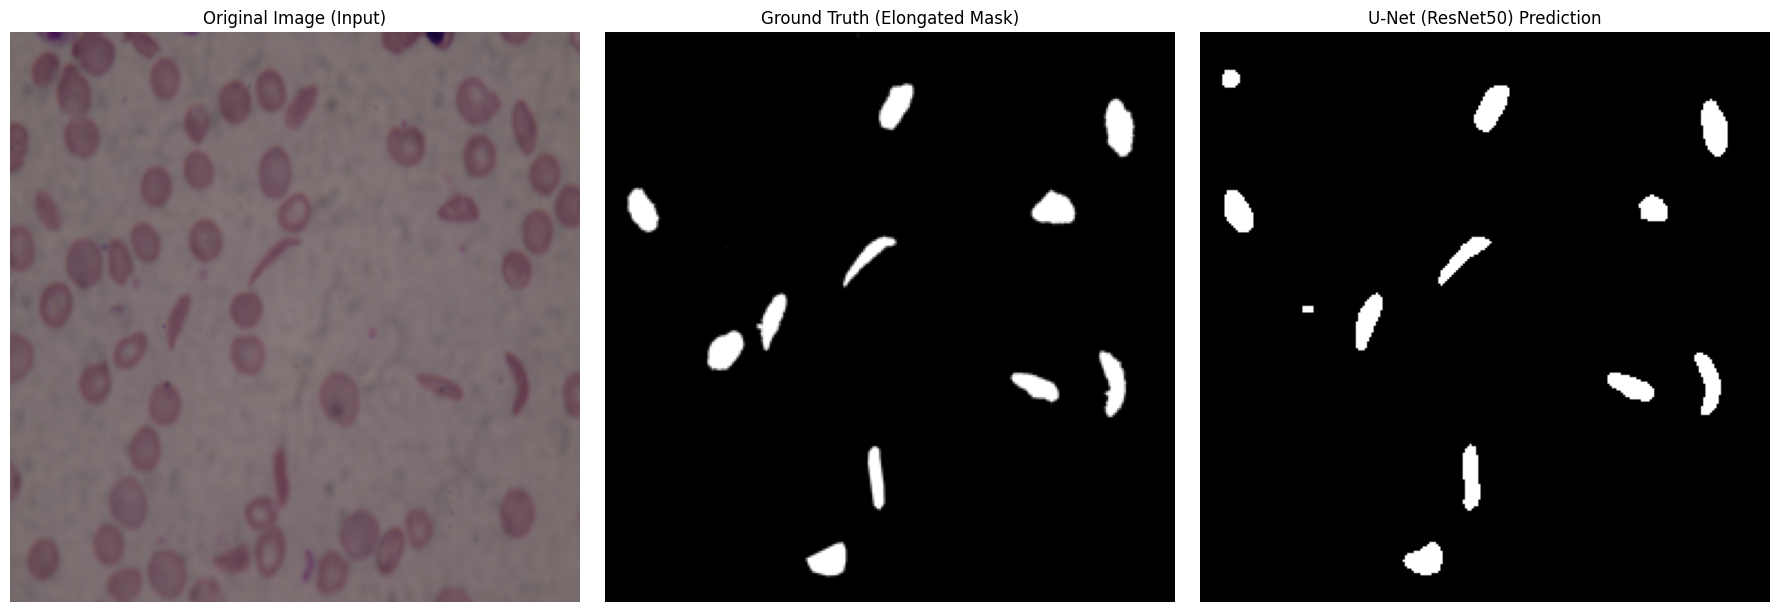

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from PIL import Image
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

# --- 1. Hyperparameters ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR_2 = "/kaggle/input/erythrocytesidb-sca/Version 2, erythrocytesIDB 2021/erythrocytesIDB2"
DATA_DIR_3 = "/kaggle/input/erythrocytesidb-sca/Version 2, erythrocytesIDB 2021/erythrocytesIDB3"
ENCODER = "resnet50"
ENCODER_WEIGHTS = "imagenet"
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 100 # We'll run for 10 epochs for a good result
LR = 1e-4

# --- 2. Custom Dataset (using Albumentations) ---
class SCA_Dataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None, preprocessing=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        self.preprocessing = preprocessing

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image and mask
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L")) # Grayscale
        
        # Binarize mask
        mask = (mask > 128).astype(np.float32)

        # Apply Albumentations
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        # Apply preprocessing (normalization for ResNet)
        if self.preprocessing:
            # Preprocessing expects HWC, ToTensorV2 outputs CHW
            # So we move preprocessing before ToTensorV2 in the transform
            pass

        # Add channel dimension to mask (H, W) -> (1, H, W)
        mask = mask.unsqueeze(0)
        
        return image, mask

# --- 3. Data Augmentation & Loading ---
def get_transforms(preprocessing_fn):
    # Augmentations for the training set
    train_transform = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.Lambda(image=preprocessing_fn), # Apply ResNet normalization
        ToTensorV2(), # Converts HWC -> CHW and to tensor
    ])

    # Only resizing and normalization for validation
    val_transform = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Lambda(image=preprocessing_fn), # Apply ResNet normalization
        ToTensorV2(),
    ])
    return train_transform, val_transform

def get_loaders(data_dir_2, data_dir_3, preprocessing_fn):
    # Find all source/mask pairs
    image_paths = []
    mask_paths = []
    
    folders = glob.glob(os.path.join(data_dir_2, "*")) + glob.glob(os.path.join(data_dir_3, "*"))
    
    for folder in folders:
        if not os.path.isdir(folder): continue
        
        img_path = os.path.join(folder, "source.jpg")
        mask_path = os.path.join(folder, "mask-elongated.jpg") # <-- The key change
        
        if os.path.exists(img_path) and os.path.exists(mask_path):
            image_paths.append(img_path)
            mask_paths.append(mask_path)
            
    print(f"Total elongated image/mask pairs found: {len(image_paths)}")

    # Split into train and validation sets
    train_imgs, val_imgs, train_masks, val_masks = train_test_split(
        image_paths, mask_paths, test_size=0.2, random_state=42
    )

    # Get transforms
    train_transform, val_transform = get_transforms(preprocessing_fn)

    # Create datasets
    train_ds = SCA_Dataset(train_imgs, train_masks, transform=train_transform)
    val_ds = SCA_Dataset(val_imgs, val_masks, transform=val_transform)

    # Create dataloaders
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    return train_loader, val_loader

# --- 4. Training and Validation Functions ---
def train_fn(loader, model, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    
    for (data, targets) in loader:
        data = data.to(device=device, dtype=torch.float)
        targets = targets.to(device=device, dtype=torch.float)
        
        # Forward
        predictions = model(data)
        loss = loss_fn(predictions, targets)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    return total_loss / len(loader)

def eval_fn(loader, model, loss_fn, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for (data, targets) in loader:
            data = data.to(device=device, dtype=torch.float)
            targets = targets.to(device=device, dtype=torch.float)
            
            predictions = model(data)
            loss = loss_fn(predictions, targets)
            total_loss += loss.item()
            
            # Store for metrics
            preds_binary = (torch.sigmoid(predictions) > 0.5).float()
            all_preds.append(preds_binary.cpu())
            all_targets.append(targets.cpu())
            
    # Calculate Dice score (a common segmentation metric)
    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    
    # Dice = 2 * (A intersection B) / (|A| + |B|)
    intersection = (all_preds * all_targets).sum()
    total_pixels = all_preds.sum() + all_targets.sum()
    dice_score = (2. * intersection + 1e-6) / (total_pixels + 1e-6) # 1e-6 for stability
    
    return total_loss / len(loader), dice_score.item()

# --- 5. Main Execution ---
print(f"Using device: {DEVICE}")

# Get the specific normalization for ResNet50
preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, ENCODER_WEIGHTS)

# Get dataloaders
train_loader, val_loader = get_loaders(DATA_DIR_2, DATA_DIR_3, preprocessing_fn)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# Define Model, Loss, Optimizer
model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=3,
    classes=1, # 1 output channel (binary mask)
).to(DEVICE)

# Loss: Combo of Dice Loss and BCE Loss is very robust
loss_fn_dice = smp.losses.DiceLoss(mode='binary')
loss_fn_bce = nn.BCEWithLogitsLoss() # Numerically stable
def combined_loss(pred, target):
    return 0.5 * loss_fn_bce(pred, target) + 0.5 * loss_fn_dice(pred, target)

optimizer = optim.Adam(model.parameters(), lr=LR)

print("\n--- Starting Training ---")
best_dice = -1.0

for epoch in range(EPOCHS):
    train_loss = train_fn(train_loader, model, optimizer, combined_loss, DEVICE)
    val_loss, val_dice = eval_fn(val_loader, model, combined_loss, DEVICE)
    
    print(f"Epoch {epoch+1}/{EPOCHS} -> Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")
    
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  -> New best model saved! (Dice: {val_dice:.4f})")
        
print("--- Training Complete ---")
print(f"Best validation Dice score: {best_dice:.4f}")

# --- 6. Visualize Predictions ---
print("\nLoading best model for visualization...")
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# Get one sample from validation set
val_ds = val_loader.dataset
img_path = val_ds.image_paths[0]
mask_path = val_ds.mask_paths[0]

# Load original image
original_img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
original_mask = Image.open(mask_path).convert("L").resize((IMG_SIZE, IMG_SIZE))

# Get dataset item (which is transformed)
image_tensor, target_mask = val_ds[0]

with torch.no_grad():
    # Model expects a batch, so add batch dimension (C, H, W) -> (1, C, H, W)
    input_tensor = image_tensor.to(device=DEVICE, dtype=torch.float).unsqueeze(0)
    
    # Get prediction
    pred_logits = model(input_tensor)
    
    # Convert prediction to a binary mask
    # 1. Apply sigmoid to get probabilities (0-1)
    # 2. Threshold at 0.5
    pred_mask = (torch.sigmoid(pred_logits) > 0.5).float()
    
    # Move to CPU and remove batch/channel dimensions for plotting
    pred_mask_cpu = pred_mask.cpu().squeeze(0).squeeze(0)
    target_mask_cpu = target_mask.squeeze(0)
    
# Plot the results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_img)
axes[0].set_title("Original Image (Input)")
axes[0].axis("off")

axes[1].imshow(original_mask, cmap='gray')
axes[1].set_title("Ground Truth (Elongated Mask)")
axes[1].axis("off")

axes[2].imshow(pred_mask_cpu, cmap='gray')
axes[2].set_title("U-Net (ResNet50) Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Libraries installed.
Using device: cuda
Total multi-class image/mask sets found: 79
Train batches: 8, Val batches: 2

--- Starting Training ---
Epoch 1/100 -> Train Loss: 0.9056 | Val Loss: 0.8925 | Val Dice (Macro): 0.2111
  -> New best model saved! (Dice: 0.2111)
Epoch 2/100 -> Train Loss: 0.7228 | Val Loss: 0.7321 | Val Dice (Macro): 0.1876
Epoch 3/100 -> Train Loss: 0.6182 | Val Loss: 0.6743 | Val Dice (Macro): 0.2458
  -> New best model saved! (Dice: 0.2458)
Epoch 4/100 -> Train Loss: 0.5606 | Val Loss: 0.6173 | Val Dice (Macro): 0.3010
  -> New best model saved! (Dice: 0.3010)
Epoch 5/100 -> Train Loss: 0.5161 | Val Loss: 0.6052 | Val Dice (Macro): 0.3289
  -> New best model saved! (Dice: 0.3289)
Epoch 6/100 -> Train Loss: 0.4848 | Val Loss: 0.5598 | Val Dice (Macro): 0.3466
  -> New best model saved! (Dice: 0.3466)
Epoch 7/100 -> Train Loss: 0.4348 | Val Loss: 0.5174 | Val Dice (Macro): 0.3617
  -> New best model saved! (Dice: 0.3617)
Epoch 8/100 -> Train Loss: 0.4178 | Val Loss

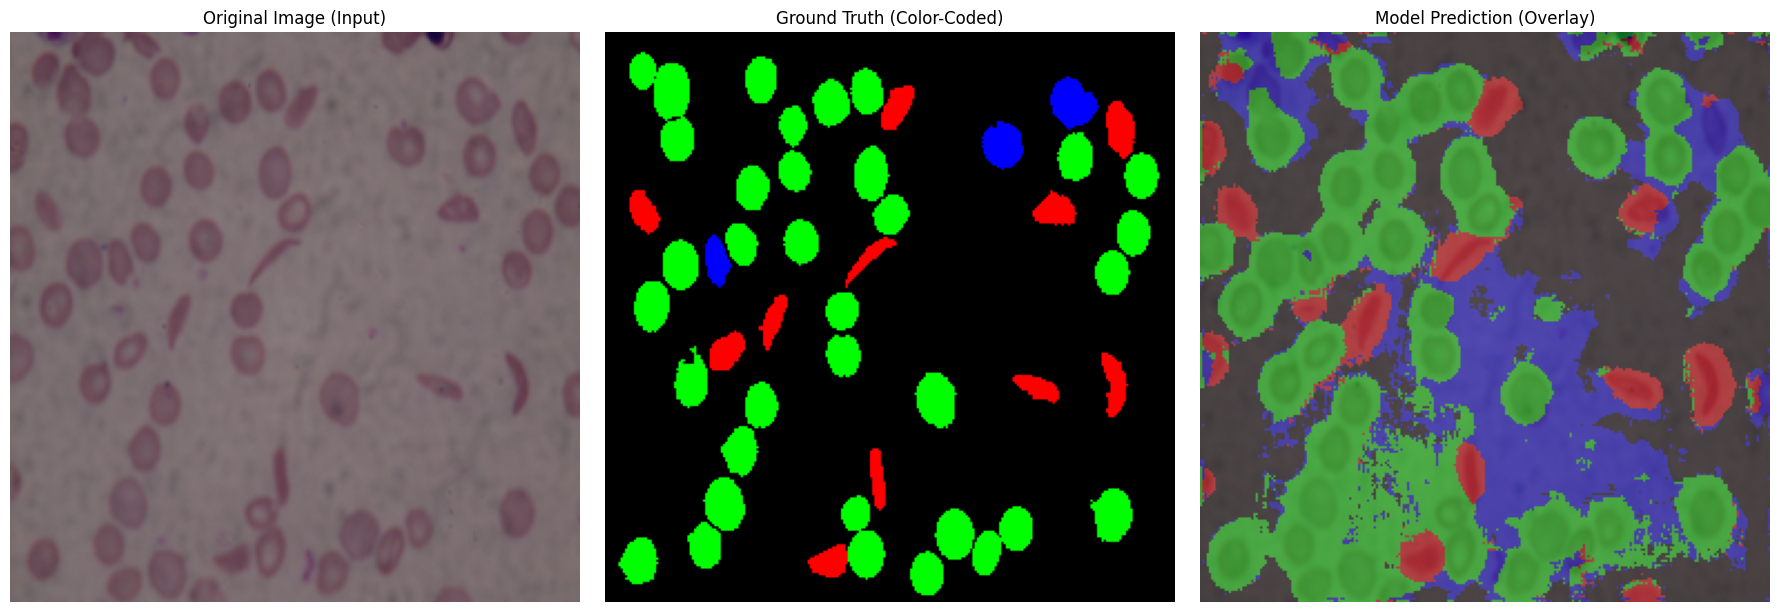

In [25]:
!pip install segmentation-models-pytorch albumentations -q
print("Libraries installed.")
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import segmentation_models_pytorch.metrics as smp_metrics
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from PIL import Image
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import cv2 # Added for visualization

# --- 1. Hyperparameters ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR_2 = "/kaggle/input/erythrocytesidb-sca/Version 2, erythrocytesIDB 2021/erythrocytesIDB2"
DATA_DIR_3 = "/kaggle/input/erythrocytesidb-sca/Version 2, erythrocytesIDB 2021/erythrocytesIDB3"
ENCODER = "resnet50"
ENCODER_WEIGHTS = "imagenet"
IMG_SIZE = 256
BATCH_SIZE = 8
# Running for more epochs is good for segmentation
EPOCHS = 100 # Fixed unicode space here
LR = 1e-4

# --- 2. Custom Dataset (Multi-Class) ---
class SCA_Dataset(Dataset):
    def __init__(self, image_paths, transform=None, preprocessing=None):
        self.image_paths = image_paths
        self.transform = transform
        self.preprocessing = preprocessing

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        
        # Derive mask paths from image path
        folder_path = os.path.dirname(self.image_paths[idx])
        mask_c_path = os.path.join(folder_path, "mask-circular.jpg")
        mask_e_path = os.path.join(folder_path, "mask-elongated.jpg")
        mask_o_path = os.path.join(folder_path, "mask-other.jpg")

        # Load individual binary masks
        mask_c = np.array(Image.open(mask_c_path).convert("L"))
        mask_e = np.array(Image.open(mask_e_path).convert("L"))
        mask_o = np.array(Image.open(mask_o_path).convert("L"))
        
        # Create a single multi-class mask (H, W)
        # 0=background, 1=circular, 2=elongated, 3=other
        # We use float32 as required by albumentations
        H, W = mask_c.shape
        mask = np.zeros((H, W), dtype=np.float32)
        mask[mask_c > 128] = 1.0  # Class 1
        mask[mask_e > 128] = 2.0  # Class 2
        mask[mask_o > 128] = 3.0  # Class 3
        
        # Apply Albumentations
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        # Convert mask to LongTensor (required by CrossEntropyLoss)
        # (H, W) with class indices
        mask = mask.long()
        
        return image, mask

# --- 3. Data Augmentation & Loading ---
def get_transforms(preprocessing_fn):
    # Augmentations for the training set
    train_transform = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.Lambda(image=preprocessing_fn), # Apply ResNet normalization
        ToTensorV2(), # Converts image to (C, H, W) and mask to (H, W)
    ])

    # Only resizing and normalization for validation
    val_transform = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Lambda(image=preprocessing_fn), # Apply ResNet normalization
        ToTensorV2(),
    ])
    return train_transform, val_transform

def get_loaders(data_dir_2, data_dir_3, preprocessing_fn):
    # Find all source images that have all 3 corresponding masks
    image_paths = []
    
    folders = glob.glob(os.path.join(data_dir_2, "*")) + glob.glob(os.path.join(data_dir_3, "*"))
    
    for folder in folders:
        if not os.path.isdir(folder): continue
        
        img_path = os.path.join(folder, "source.jpg")
        mask_c_path = os.path.join(folder, "mask-circular.jpg")
        mask_e_path = os.path.join(folder, "mask-elongated.jpg")
        mask_o_path = os.path.join(folder, "mask-other.jpg")
        
        # Only add if all files exist
        if all(os.path.exists(p) for p in [img_path, mask_c_path, mask_e_path, mask_o_path]):
            image_paths.append(img_path)
            
    print(f"Total multi-class image/mask sets found: {len(image_paths)}")

    # Split into train and validation sets
    train_imgs, val_imgs = train_test_split(
        image_paths, test_size=0.2, random_state=42
    )

    # Get transforms
    train_transform, val_transform = get_transforms(preprocessing_fn)

    # Create datasets
    train_ds = SCA_Dataset(train_imgs, transform=train_transform)
    val_ds = SCA_Dataset(val_imgs, transform=val_transform)

    # Create dataloaders
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    return train_loader, val_loader

# --- 4. Training and Validation Functions ---
def train_fn(loader, model, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    
    for (data, targets) in loader:
        data = data.to(device=device, dtype=torch.float)
        # Target must be LongTensor for CrossEntropy
        targets = targets.to(device=device, dtype=torch.long) 
        
        # Forward
        predictions = model(data)
        loss = loss_fn(predictions, targets)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    return total_loss / len(loader)

# -----------------------------------------------------------------
# --- THIS IS THE FULLY CORRECTED EVALUATION FUNCTION ---
# -----------------------------------------------------------------
# -----------------------------------------------------------------
# --- THIS IS THE FULLY CORRECTED EVALUATION FUNCTION ---
# -----------------------------------------------------------------
def eval_fn(loader, model, loss_fn, device):
    model.eval()
    total_loss = 0.0
    
    # Accumulate stats over all batches
    total_tp = None
    total_fp = None
    total_fn = None
    total_tn = None

    with torch.no_grad():
        for (data, targets) in loader:
            data = data.to(device=device, dtype=torch.float)
            targets = targets.to(device=device, dtype=torch.long)
            
            predictions_logits = model(data) # Output shape (N, 4, H, W)
            loss = loss_fn(predictions_logits, targets)
            total_loss += loss.item()
            
            # --- THIS IS THE FIX ---
            # Convert (N, C, H, W) logits to (N, H, W) class indices
            # This is what get_stats expects as input
            predictions_indices = torch.argmax(predictions_logits, dim=1)
            # --- END OF FIX ---

            # Get stats for this batch using the correct mode
            tp, fp, fn, tn = smp.metrics.get_stats(
                predictions_indices,  # <-- Pass the integer indices
                targets, 
                mode='multiclass', 
                num_classes=4 # We have 4 classes (0, 1, 2, 3)
            )
            
            # Accumulate stats over all batches
            if total_tp is None:
                total_tp = tp
                total_fp = fp
                total_fn = fn
                total_tn = tn
            else:
                total_tp += tp
                total_fp += fp
                total_fn += fn
                total_tn += tn
            # --- End of batch logic ---
            
    # --- Calculate metrics AFTER the loop from accumulated stats ---
    # Calculate F1 score from the total stats for all classes
    f1_per_class = smp.metrics.f1_score(
        total_tp, 
        total_fp, 
        total_fn, 
        total_tn, 
        reduction=None # Get F1 for each class
    )
    
    # We want the average of classes 1, 2, and 3 (circ, elong, other).
    # Slice the tensor to exclude class 0 (background) and take the mean.
    if f1_per_class.numel() > 1:
        # f1_per_class[0] is for background
        # f1_per_class[1] is for circular
        # f1_per_class[2] is for elongated
        # f1_per_class[3] is for other
        mean_f1_macro = f1_per_class[1:].mean()
    else:
        mean_f1_macro = f1_per_class.mean() # Fallback

    return total_loss / len(loader), mean_f1_macro.item()
# --- END OF CORRECTED FUNCTION ---
# --- 5. Main Execution ---
print(f"Using device: {DEVICE}")

# Get the specific normalization for ResNet50
preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, ENCODER_WEIGHTS)

# Get dataloaders
train_loader, val_loader = get_loaders(DATA_DIR_2, DATA_DIR_3, preprocessing_fn)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# Define Model, Loss, Optimizer
model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=3,
    classes=4, # <-- CHANGED: 0=bg, 1=circ, 2=elong, 3=other
).to(DEVICE)

# Loss: Combo of Dice Loss and CrossEntropy Loss
loss_fn_ce = nn.CrossEntropyLoss(ignore_index=0) # Ignore background
loss_fn_dice = smp.losses.DiceLoss(
    mode='multiclass', 
    from_logits=True, 
    ignore_index=0 # Ignore background
)

def combined_loss(pred, target):
    # pred shape: (N, C, H, W), target shape: (N, H, W)
    return 0.5 * loss_fn_ce(pred, target) + 0.5 * loss_fn_dice(pred, target)

optimizer = optim.Adam(model.parameters(), lr=LR)

print("\n--- Starting Training ---")
best_dice = -1.0

for epoch in range(EPOCHS):
    train_loss = train_fn(train_loader, model, optimizer, combined_loss, DEVICE)
    val_loss, val_dice = eval_fn(val_loader, model, combined_loss, DEVICE)
    
    print(f"Epoch {epoch+1}/{EPOCHS} -> Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Dice (Macro): {val_dice:.4f}")
    
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "best_multiclass_model.pth")
        print(f"  -> New best model saved! (Dice: {val_dice:.4f})")
        
print("--- Training Complete ---")
print(f"Best validation Dice score (Macro): {best_dice:.4f}")

# --- 6. Visualization Function ---
# Define our color map
# 0=Black (BG), 1=Green (Circ), 2=Red (Elong), 3=Blue (Other)
COLORMAP = {
    0: (0, 0, 0),       # Background
    1: (0, 255, 0),     # Circular (Green)
    2: (255, 0, 0),     # Elongated (Red)
    3: (0, 0, 255)      # Other (Blue)
}

def create_color_mask(mask, colormap):
    """Converts a (H, W) class-index mask to a (H, W, 3) RGB mask."""
    # Start with a black image
    rgb_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    
    # Apply color for each class
    for class_id, color in colormap.items():
        rgb_mask[mask == class_id] = color
    return rgb_mask

# --- 7. Visualize Predictions ---
print("\nLoading best model for visualization...")
model.load_state_dict(torch.load("best_multiclass_model.pth"))
model.eval()

# Get one sample from validation set
val_ds = val_loader.dataset
image_tensor, target_mask = val_ds[0] # target_mask is (H, W) LongTensor

# Get original image for pretty plotting
original_img = Image.open(val_ds.image_paths[0]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))

with torch.no_grad():
    # FIX: Add dtype=torch.float to match model weights
    input_tensor = image_tensor.to(device=DEVICE, dtype=torch.float).unsqueeze(0)
    
    # Get prediction
    pred_logits = model(input_tensor) # (1, 4, H, W)
    
    # Convert prediction to class indices
    pred_mask = torch.argmax(pred_logits, dim=1) # (1, H, W)
    pred_mask_cpu = pred_mask.cpu().squeeze(0) # (H, W)
    
# Convert masks to color RGB images
target_color_mask = create_color_mask(target_mask.numpy(), COLORMAP)
pred_color_mask = create_color_mask(pred_mask_cpu.numpy(), COLORMAP)

# Create overlay
# Convert PIL image to numpy array
original_img_np = np.array(original_img)
# Blend original image with the prediction mask
overlay = cv2.addWeighted(original_img_np, 0.6, pred_color_mask, 0.4, 0)
    
# Plot the results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_img)
axes[0].set_title("Original Image (Input)")
axes[0].axis("off")

axes[1].imshow(target_color_mask)
axes[1].set_title("Ground Truth (Color-Coded)")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Model Prediction (Overlay)")
axes[2].axis("off")

plt.tight_layout()
plt.show()